In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
from datetime import datetime
import itertools
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from pathlib import Path
import random
import regex as re
import sys
import tldextract
import seaborn as sns
sys.path.append(str(Path(f"../../../global_helpers").resolve()))
sys.path.append(str(Path(f"../../../longitudinal/analysis/plotting").resolve()))
from connecttodb import connect_to_db
from generate_httparchive_dates import generate_crawl_identifiers
from plotting_helpers import quick_cdf
from histplot import *

In [32]:
conn = connect_to_db()
conn.autocommit = True
cursor = conn.cursor()

In [33]:

style_path = Path(f"../../../global_helpers/theme_bw.mplstyle").resolve()
plt.style.use(style_path)
fig_path = Path(f"../../../../paper/img/httparchive/").resolve()
data_path = Path(f"../../../../data/httparchive/summary/ast/threshold5/").resolve()
window_data_path = Path(f"../../../../data/httparchive/summary/ast/window_overlap.json").resolve()

In [34]:
with open(window_data_path) as json_file:
    window_data = json.load(json_file)


In [35]:
plt.style.use(style_path)
plt.style.use(Path(f"../../../../code/global_helpers/theme_bw.mplstyle").resolve())
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["#77AADD", "#99DDFF", "#44BB99", "#BBCC33","#AAAA00","#EEDD88", "#EE8866","#FFAABB", "#DDDDDD"])

plt.clf()

<Figure size 640x480 with 0 Axes>

In [36]:
def group_time_delts(months):
    if months == 1:
        return "1 Month"
    elif months <= 6:
        return "2 - 6 Months"
    elif months <=12:
        return "7 Months - 1 Year"
    return "Over 1 Year"

In [37]:
crawl_identifiers = generate_crawl_identifiers()
#crawl_identifiers = crawl_identifiers[:-2]
print(crawl_identifiers)



['2024-11-1', '2024-12-1', '2025-1-1', '2025-2-1', '2025-3-1', '2025-4-1', '2025-5-1', '2025-6-1', '2025-7-1', '2025-8-1', '2025-9-1', '2025-10-1', '2025-11-1', '2025-12-1', '2026-1-1', '2026-2-1', '2026-3-1', '2026-4-1', '2026-5-1', '2026-6-1']


In [38]:
print(len(list(itertools.combinations(crawl_identifiers, 2))))

190


In [39]:

    
total = 0
total_comparisons = 0
total_completed_all_files = 0
total_sucess = 0

not_same = 0
code_diffs_21 = list()   
code_diffs_21_inverted = list()

time_diff_21 = dict()
time_diff_21_inverted = dict()
time_groups_diff_21_inverted = dict()

code_similarity = list()
code_similarity_ref = list()
time_similarity = dict()

code_len_change = list()
time_len_change = dict()
errors = 0 
empty_resp = 0

error_dict = dict()

sample_prop = None
stored = 0

not_done_combos= [] 

not_same_all_scripts = 0

missing_files = 0

up_to_prop = 1
up_to_prop_done = 0

for y1, y2 in list(itertools.combinations(crawl_identifiers, 2)):
    d1 = datetime.strptime(y1,"%Y-%m-%d")
    d2 = datetime.strptime(y2,"%Y-%m-%d")
    # Calculate difference
    time_delta = int(round((d2 - d1).days/30, 0))
    grouped_delta = group_time_delts(time_delta)
    
    path = os.path.join(data_path,f"{y1}_{y2}_ast_data.json")
    
    
    
    if os.path.isfile(path):
        #print(path)
        try:
            with open(path) as json_file:
                ast_data = json.load(json_file)
                
                
                if sample_prop:
                    num_done = len(ast_data["done"])
                    num_error = len(ast_data["errors"])
                    total_completed = num_done+num_error
                    sample_num = round((num_done+len(ast_data["todo"])+num_error)*sample_prop)
                    
                    ast_data["done"] = random.sample(ast_data["done"], min(num_done,round(sample_num*(num_done/ total_completed))))
                    ast_data["errors"] = random.sample(ast_data["errors"], min(num_error, round(sample_num*(num_error/ total_completed))))
                    if len(ast_data["done"])<round(sample_num*(num_done/ total_completed)):
                        print(f"not enough done?: {len(ast_data['done'])} {round(sample_num*(num_done/ total_completed))}")
                
                
                
                
                
        except Exception as e: 
            raise  f"Failed to open json: {e}"
              
        if len(ast_data["done"])==0:
            print(y1, y2, f"nothing done in file")
        
        
        total_comparisons += len(ast_data["errors"]) + len(ast_data["done"]) + len(ast_data["todo"])
        total_sucess += len(ast_data["done"])
        total_completed_all_files += len(ast_data["errors"]) + len(ast_data["done"])
        
        
        
        prop_done = (len(ast_data["errors"]) + len(ast_data["done"])) / (len(ast_data["errors"]) + len(ast_data["done"]) + len(ast_data["todo"]))
        if  prop_done>= up_to_prop-.002:
            up_to_prop_done += 1
        elif not prop_done == 1:
            print(y1, y2,  prop_done*100, len(ast_data["done"])) 
        
        
        
        
        #Classify Errors
        for req_comp_data in ast_data["errors"]:
            e = req_comp_data[1]
            if ('\'import\' and \'export\' may appear only with \'sourceType: "module"\'' in e or 
                'import.meta may appear only with' in e):
                e = "Import/Export"   
            elif e == "list index out of range":
                e = "Truncated Script"         
            error_dict[e] =  error_dict.get(e, 0) +1
        
        # Analysis of sucessful comparisons  
        
        for req_comp_data in ast_data["done"]:
            #try:
                comp21 = json.loads(req_comp_data[1].rstrip())
                #comp12 = json.loads(req_comp_data[2].rstrip())
                #l1 = int(req_comp_data[2])
                #l2 = int(req_comp_data[3])
                
                
                code_diffs_21.append(comp21["normalized"])
                #code_similarity.append((comp21["normalized"]+comp12["normalized"])/2)
                #code_len_change.append((l2-l1)/l1)
                
                code_diffs_21_inverted.append(1-comp21["normalized"])
                
                
                page = tldextract.extract(req_comp_data[0][0]).top_domain_under_public_suffix 
                r11 = tldextract.extract(req_comp_data[0][2]).top_domain_under_public_suffix if req_comp_data[0][2] else None
                r12 = tldextract.extract(req_comp_data[0][3]).top_domain_under_public_suffix if req_comp_data[0][3] else None


                
                # if (r11!="" and page==r11) or (r12!="" and page==r12):
                #     code_similarity_ref.append((comp21["normalized"]+comp12["normalized"])/2)
                #     total +=1
                #     if comp21["normalized"]!=1 and comp12["normalized"]!=1:
                #         not_same+=1
                        
                # if comp21["normalized"]!=1 and comp12["normalized"]!=1:
                #     not_same_all_scripts+=1
                    
                    
                   
                
                time_diff_21[time_delta] = time_diff_21.get(time_delta, list())
                time_diff_21_inverted[time_delta] = time_diff_21_inverted.get(time_delta, list())
                time_groups_diff_21_inverted[grouped_delta] = time_groups_diff_21_inverted.get(grouped_delta, list())
                
                #time_similarity[time_delta] = time_similarity.get(time_delta, list())
                time_len_change[time_delta] = time_len_change.get(time_delta, list())
                
                
                
                time_diff_21[time_delta].append(comp21["normalized"])
                time_diff_21_inverted[time_delta].append(1-comp21["normalized"])
                time_groups_diff_21_inverted[grouped_delta].append(1-comp21["normalized"])
                #time_similarity[time_delta].append((comp21["normalized"]+comp12["normalized"])/2)
                #time_len_change[time_delta].append((l2-l1)/l1)
                
            # except Exception as e:
            #     print(e)
            #     errors+=1
    else:
        missing_files+=1
        #print(y1, y2,"missing file")  
  
print(f"files done up to {up_to_prop}: {up_to_prop_done}")     
print(f"missing files: {missing_files}")      
for d in (time_diff_21, time_similarity, time_len_change):
    for k in list(d.keys()):
        if not d[k]:
            del d[k]         
            
            
        

files done up to 1: 190
missing files: 0


In [40]:
total_comparisons/18


36648.444444444445

# Overviews With Scripts Potentially Showing Up Multiple Times

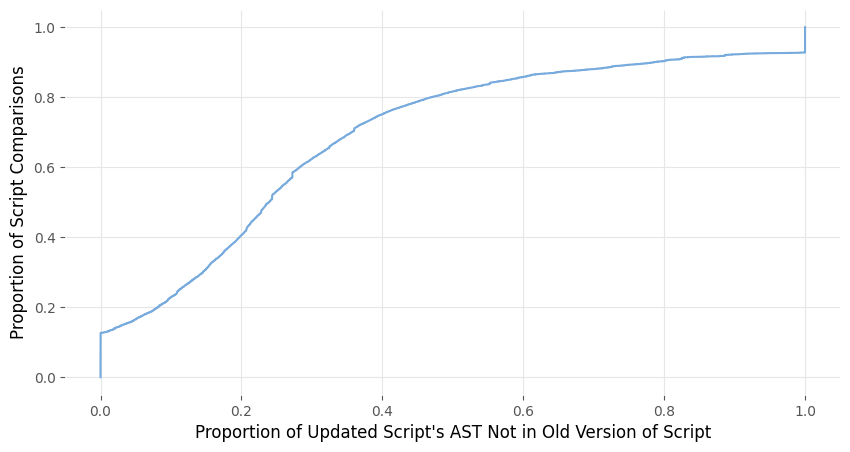

count    609644.000000
mean          0.307461
std           0.277678
min           0.000000
1%            0.000000
2.5%          0.000000
5%            0.000000
10%           0.000000
15%           0.031898
20%           0.081505
25%           0.112012
50%           0.238998
75%           0.398271
80%           0.469466
max           1.000000
dtype: float64


In [41]:
# CDF: script change metric
# x-axis: change score
# y-axis: fraction
a = code_diffs_21_inverted

plt.figure(figsize=(10, 5))
quick_cdf(a)
plt.xlabel("Proportion of Updated Script's AST Not in Old Version of Script")
plt.ylabel("Proportion of Script Comparisons")
plt.savefig(f"{fig_path}/http_audit_inverted.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()  


print(pd.Series(a).describe(percentiles=[0.01, 0.025,0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.75, 0.8]))


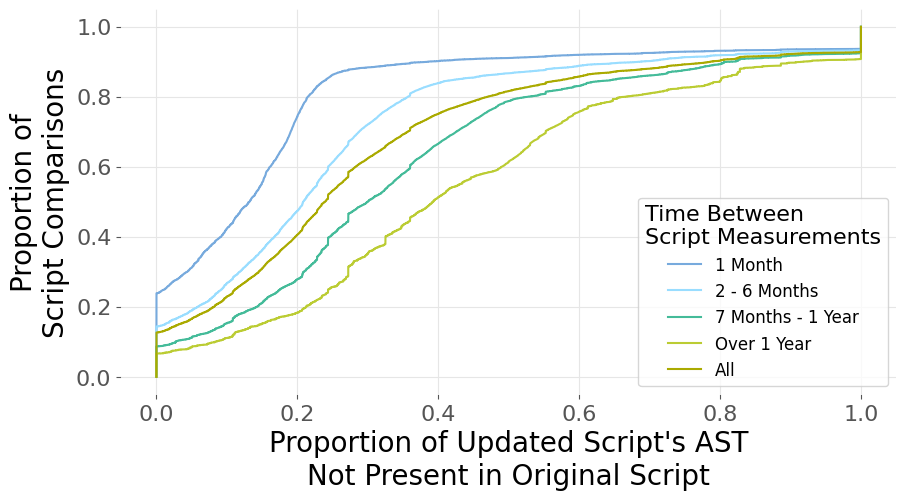

1 Month
count    65753.000000
mean         0.183065
std          0.249274
min          0.000000
25%          0.011779
50%          0.131791
75%          0.201302
90%          0.385216
max          1.000000
dtype: float64
None
Over 1 Year
count    72746.000000
mean         0.441493
std          0.283371
min          0.000000
10%          0.083333
25%          0.244442
50%          0.392316
75%          0.591698
96%          1.000000
max          1.000000
dtype: float64
None


In [42]:
plt.figure(figsize=(10, 5))


for time_period in ["1 Month", "2 - 6 Months", "7 Months - 1 Year", "Over 1 Year"]:
    a = time_groups_diff_21_inverted[time_period]
    
    plt.plot(np.sort(a), np.linspace(0, 1, len(a), endpoint=False), label = time_period, drawstyle='steps-post')
plt.plot(np.sort(code_diffs_21_inverted), np.linspace(0, 1, len(code_diffs_21_inverted), endpoint=False), label = "All", drawstyle='steps-post')    
plt.xlabel("Proportion of Updated Script's AST\nNot Present in Original Script", fontsize = 20)
plt.ylabel("Proportion of\nScript Comparisons", fontsize = 20)
plt.legend(fontsize = 12, title="Time Between\nScript Measurements", title_fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig(f"{fig_path}/http_audit_inverted_time_groups.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()  

time_period = "1 Month"
print(time_period)
a = time_groups_diff_21_inverted[time_period]
print(print(pd.Series(a).describe(percentiles=[0.25, 0.5, 0.75, 0.9])))

time_period = "Over 1 Year"
print(time_period)
a = time_groups_diff_21_inverted[time_period]
print(print(pd.Series(a).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.96])))


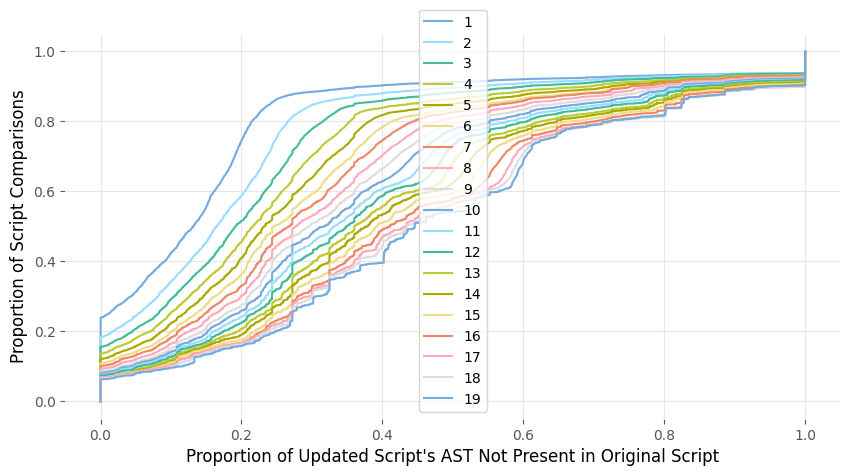

In [43]:
plt.figure(figsize=(10, 5))

for time_period in time_diff_21_inverted.keys():
    a = time_diff_21_inverted[time_period]
    plt.plot(np.sort(a), np.linspace(0, 1, len(a), endpoint=False), label = time_period)
    
plt.xlabel("Proportion of Updated Script's AST Not Present in Original Script")
plt.ylabel("Proportion of Script Comparisons")
plt.legend()
plt.savefig(f"{fig_path}/http_audit_inverted_time_all.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()  

if older file was audited how much of newer file has been audited


/tmp/ipykernel_1986961/2895594322.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(sorted_values, labels=sorted_keys, showfliers=False)


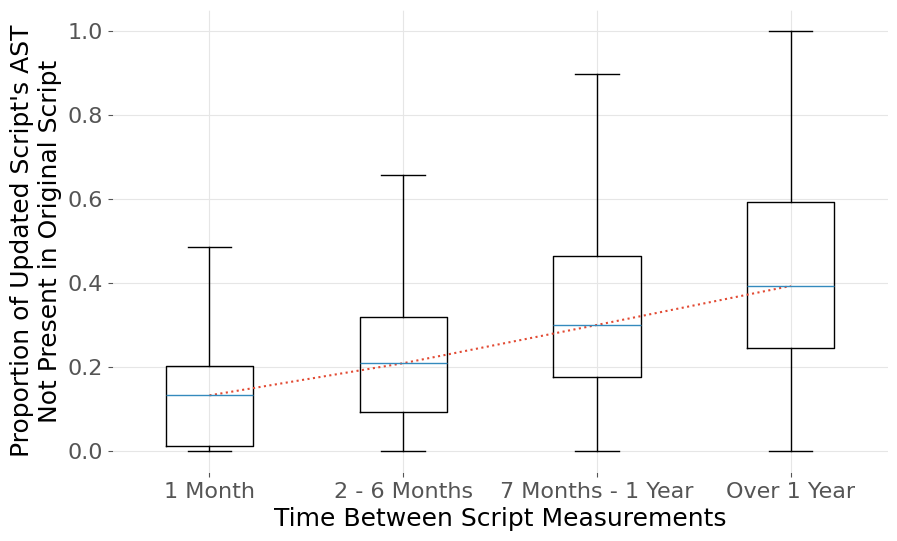

In [44]:
with plt.style.context(style_path):     
    plt.figure(figsize=(10, 6))
    print("if older file was audited how much of newer file has been audited")
    sorted_keys = ["1 Month", "2 - 6 Months", "7 Months - 1 Year", "Over 1 Year"]
    sorted_values = [time_groups_diff_21_inverted[k] for k in sorted_keys]
    bp = plt.boxplot(sorted_values, labels=sorted_keys, showfliers=False)
                    

    medians_y = [line.get_ydata()[0] for line in bp['medians']]
    medians_x = [np.mean(line.get_xdata()) for line in bp['medians']]
    plt.plot(medians_x, medians_y, ':', label='Median')

    plt.ylabel("Proportion of Updated Script's AST\nNot Present in Original Script", fontsize = 18)
    plt.xlabel("Time Between Script Measurements", fontsize = 18)
    #plt.legend(fontsize = 12, title="Time Between\nScript Measurements", title_fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.savefig(f"{fig_path}/http_audit_over_time_grouped_box_inverted.pdf",bbox_inches="tight", format='pdf', dpi=1200)
    plt.show()  

/tmp/ipykernel_1986961/1482722636.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(sorted_values, labels=sorted_keys, showfliers=False)


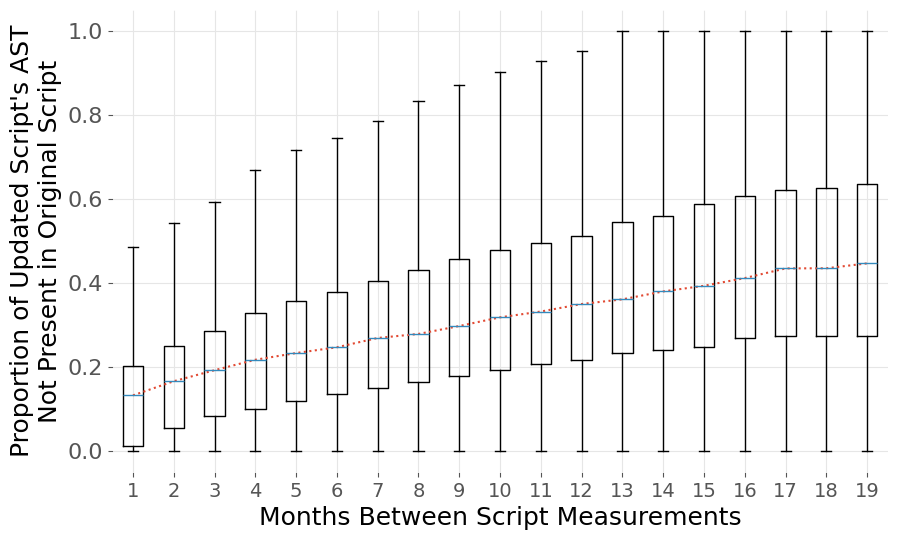

In [45]:
with plt.style.context(style_path):     
    plt.figure(figsize=(10, 6))
    sorted_keys = list(time_diff_21_inverted.keys())
    sorted_values = [time_diff_21_inverted[k] for k in sorted_keys]
    bp = plt.boxplot(sorted_values, labels=sorted_keys, showfliers=False)
                    

    medians_y = [line.get_ydata()[0] for line in bp['medians']]
    medians_x = [np.mean(line.get_xdata()) for line in bp['medians']]
    plt.plot(medians_x, medians_y, ':', label='Median')

    plt.ylabel("Proportion of Updated Script's AST\nNot Present in Original Script", fontsize = 18)
    plt.xlabel("Months Between Script Measurements", fontsize = 18)
    #plt.legend(fontsize = 12, title="Time Between\nScript Measurements", title_fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=16)
    plt.savefig(f"{fig_path}/http_audit_over_time_box_inverted.pdf",bbox_inches="tight", format='pdf', dpi=1200)
    plt.show()  

/home/nisenoff/downstream-pets/downstream-pets/code/longitudinal/analysis/plotting/histplot.py:9: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.0) #overlap
/home/nisenoff/downstream-pets/downstream-pets/code/longitudinal/analysis/plotting/histplot.py:25: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(f"{img_path}/{save}",bbox_inches="tight", format='pdf', dpi=1200)
/home/nisenoff/downstream-pets/downstream-pets/code/longitudinal/analysis/plotting/histplot.py:25: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(f"{img_path}/{save}",bbox_inches="tight", format='pdf', dpi=1200)
/home/nisenoff/downstream-pets/downstream-pets/venv/lib/python3.12/site-packages/IPy

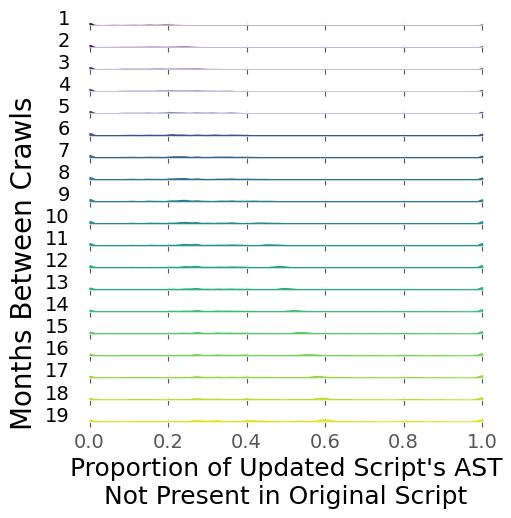

In [46]:
sorted_keys = list(time_diff_21_inverted.keys())
sorted_values = [time_diff_21_inverted[k] for k in sorted_keys]
dist_hist(sorted_keys, sorted_values, "http_audit_over_time_hist_inverted.pdf", xl="Proportion of Updated Script's AST\nNot Present in Original Script", yl="Months Between Crawls", img_path=fig_path, figsize =(5,5))

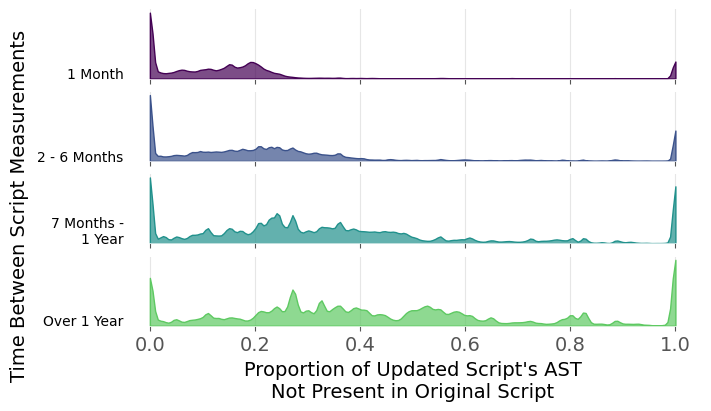

In [47]:
sorted_keys = ["1 Month", "2 - 6 Months", "7 Months -\n1 Year", "Over 1 Year"]
sorted_values = [time_groups_diff_21_inverted[k] for k in ["1 Month", "2 - 6 Months", "7 Months - 1 Year", "Over 1 Year"]]

fig, axes = plt.subplots(nrows=len(sorted_values), sharex=True, sharey=False, figsize=(7,4), layout='constrained')
#fig.subplots_adjust(hspace=0.0) #overlap
for i, ax in enumerate(axes):
    sns.kdeplot(sorted_values[i], ax=ax, fill=True, color=plt.get_cmap(plt.rcParams['image.cmap'])(i / len(sorted_values)), alpha=0.7, cut=0, bw_adjust=0.2)
    ax.patch.set_alpha(0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.text(0, 0, sorted_keys[i], transform=ax.transAxes, ha='right')
plt.xticks(fontsize=14)    
plt.xlabel("Proportion of Updated Script's AST\nNot Present in Original Script", fontsize=14)
fig.supylabel("Time Between Script Measurements", fontsize=14)
plt.savefig(f"{fig_path}/http_audit_over_time_grouped_hist_inverted.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()

# Window

<Figure size 640x480 with 0 Axes>

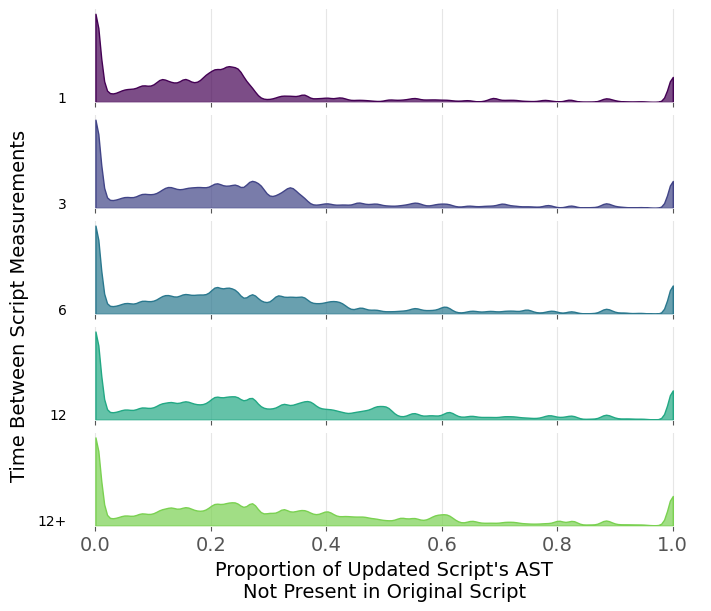

In [48]:
sorted_keys = ['1', '3', '6', '12', '12+']
sorted_values = [window_data[k]['max_values'] for k in ['1', '3', '6', '12', '100']]
plt.clf()
fig, axes = plt.subplots(nrows=len(sorted_values), sharex=True, sharey=False, figsize=(7,6), layout='constrained')
#fig.subplots_adjust(hspace=0.0) #overlap
for i, ax in enumerate(axes):
    sns.kdeplot(sorted_values[i], ax=ax, fill=True, color=plt.get_cmap(plt.rcParams['image.cmap'])(i / len(sorted_values)), alpha=0.7, cut=0, bw_adjust=0.2)
    ax.patch.set_alpha(0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.text(0, 0, sorted_keys[i], transform=ax.transAxes, ha='right')
plt.xticks(fontsize=14)    
plt.xlabel("Proportion of Updated Script's AST\nNot Present in Original Script", fontsize=14)
fig.supylabel("Time Between Script Measurements", fontsize=14)
plt.savefig(f"{fig_path}/http_audit_inverted_window_hist.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()

/tmp/ipykernel_1986961/2528885494.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(sorted_values, labels=sorted_keys, showfliers=False)


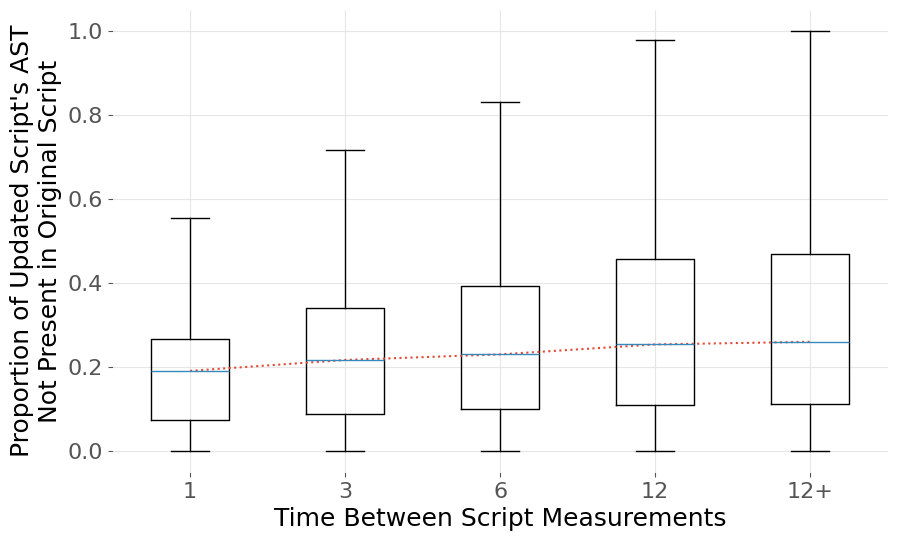

In [49]:
with plt.style.context(style_path):     
    plt.figure(figsize=(10, 6))
    sorted_keys = ['1', '3', '6', '12', '12+']
    sorted_values = [window_data[k]['max_values'] for k in ['1', '3', '6', '12', '100']]
    bp = plt.boxplot(sorted_values, labels=sorted_keys, showfliers=False)
                    

    medians_y = [line.get_ydata()[0] for line in bp['medians']]
    medians_x = [np.mean(line.get_xdata()) for line in bp['medians']]
    plt.plot(medians_x, medians_y, ':', label='Median')

    plt.ylabel("Proportion of Updated Script's AST\nNot Present in Original Script", fontsize = 18)
    plt.xlabel("Time Between Script Measurements", fontsize = 18)
    #plt.legend(fontsize = 12, title="Time Between\nScript Measurements", title_fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.savefig(f"{fig_path}/http_audit_inverted_window_box.pdf",bbox_inches="tight", format='pdf', dpi=1200)
    plt.show()  

<Figure size 640x480 with 0 Axes>

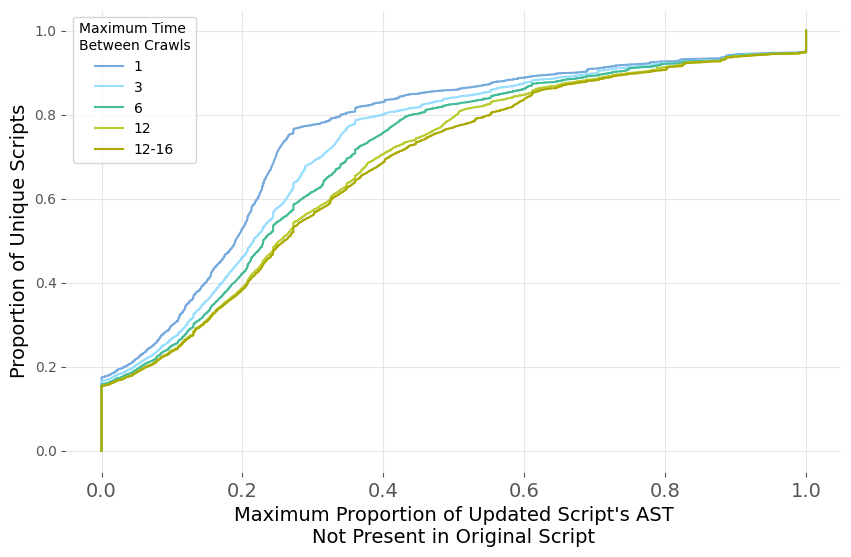

In [50]:
sorted_keys = ['1', '3', '6', '12', f'12-16']
sorted_values = [window_data[k]['max_values'] for k in ['1', '3', '6', '12', '100']]
plt.clf()
plt.figure(figsize=(10, 6))
#fig.subplots_adjust(hspace=0.0) #overlap
for  i, k in zip(sorted_keys,['1', '3', '6', '12', '100']):
    quick_cdf(window_data[k]['max_values'], label=i)

plt.xticks(fontsize=14)    
plt.ylabel("Proportion of Unique Scripts", fontsize=14)
plt.xlabel("Maximum Proportion of Updated Script's AST\nNot Present in Original Script", fontsize=14)
plt.legend(title="Maximum Time\nBetween Crawls")
plt.savefig(f"{fig_path}/http_audit_inverted_window_hist.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()

In [51]:
for k in ['1', '3', '6', '12', '100']:
    print(k)
    print(pd.Series(window_data[k]['max_values']).describe(percentiles=[0.01, 0.025,0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.75, 0.8]))


1
count    13442.000000
mean         0.245431
std          0.259931
min          0.000000
1%           0.000000
2.5%         0.000000
5%           0.000000
10%          0.000000
15%          0.000000
20%          0.033203
25%          0.072684
50%          0.190171
75%          0.265092
80%          0.340269
max          1.000000
dtype: float64
3
count    14974.000000
mean         0.274460
std          0.265397
min          0.000000
1%           0.000000
2.5%         0.000000
5%           0.000000
10%          0.000000
15%          0.000000
20%          0.046905
25%          0.086915
50%          0.216053
75%          0.338921
80%          0.399081
max          1.000000
dtype: float64
6
count    15668.000000
mean         0.294079
std          0.269141
min          0.000000
1%           0.000000
2.5%         0.000000
5%           0.000000
10%          0.000000
15%          0.000000
20%          0.055723
25%          0.100000
50%          0.229421
75%          0.393082
80%          0.440

In [52]:
sum([1 if x > .9 else 0 for x  in window_data['100']['max_values']])/18

55.55555555555556

In [53]:
sum([1 if x > 0 else 0 for x  in window_data['100']['max_values']])

13736

# Error Analysis

Total Errors: 50,028 (0.08% of 659,672 total comparisons)
Truncated Script: 36,807 (73.57%)
MissingSemicolon: 9,265 (18.52%)
NumberIdentifier: 103 (0.21%)
Import/Export: 3,460 (6.92%)
UnexpectedToken: 342 (0.68%)
UnterminatedString: 32 (0.06%)
InvalidEscapeSequence: 14 (0.03%)
AwaitNotInAsyncContext: 1 (0.00%)
UnterminatedRegExp: 4 (0.01%)


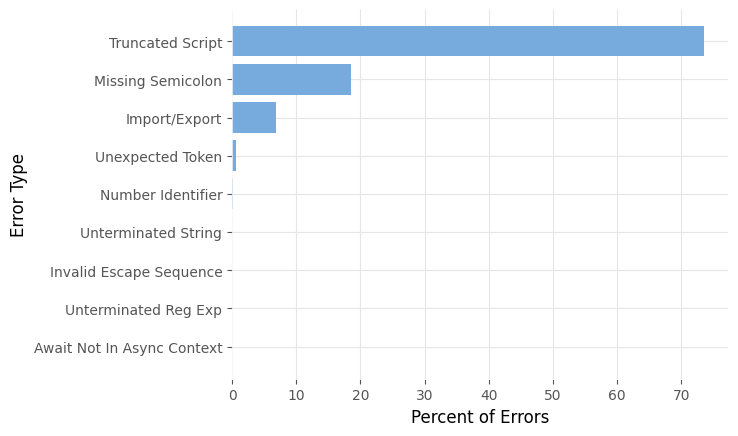

In [54]:
sorted_data = sorted(error_dict.items(), key=lambda item: item[1])
error_types, values = zip(*sorted_data)

total_errors = sum(values)

print(f"Total Errors: {total_errors:,} ({round(total_errors/total_completed_all_files,2):,.2f}% of {total_completed_all_files:,} total comparisons)")
for error in error_dict:
    print(f"{error}: {error_dict[error]:,} ({round(error_dict[error]/total_errors*100,2):,.2f}%)")

values_prop = [v/total_errors*100 for v in values]
error_types = [lbl if " " in lbl or "/" in lbl else re.sub(r'(?<!^)(?=[A-Z])', ' ', lbl) for lbl in error_types]

# plt.barh(error_types, values)
# plt.xlabel('Number of Errors')
# plt.ylabel('Error Type')
# plt.savefig(f"{fig_path}/ast_errors.pdf",bbox_inches="tight", format='pdf', dpi=1200)
# plt.show()

plt.barh(error_types, values_prop)
plt.xlabel('Percent of Errors')
plt.ylabel('Error Type')
plt.savefig(f"{fig_path}/ast_errors_prop.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()

# Old Graphs

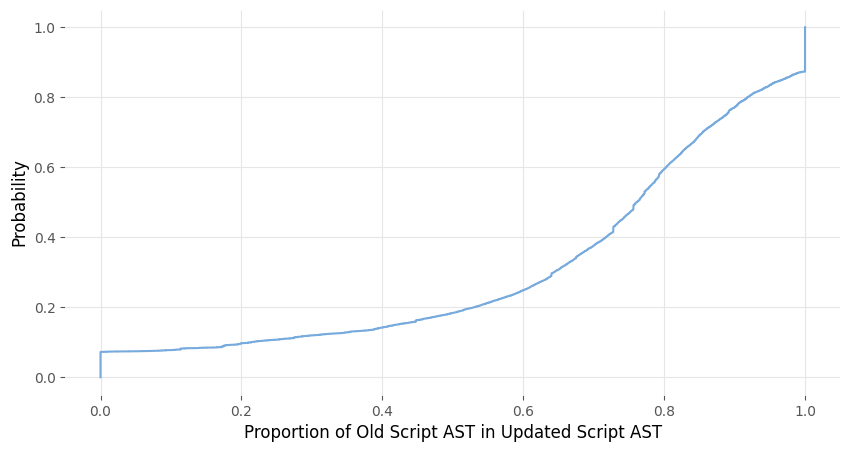

In [55]:
a = code_diffs_21
plt.figure(figsize=(10, 5))
quick_cdf(a)
plt.xlabel("Proportion of Old Script AST in Updated Script AST")
plt.ylabel("Probability")
plt.savefig(f"{fig_path}/http_audit.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()  


In [56]:
window_data['100'].keys()

dict_keys(['total_url_page_pairs', 'all_uniq_comp', 'min_values', 'max_values'])

In [57]:
len(window_data['100']['max_values'])

16224

In [58]:
window_data['100']['all_uniq_comp']/18

901.3333333333334